# 📘 Neural Network Function Fitting — Versión Avanzada
### Notebook Profesional para Clase

Generado: 2026-03-04

---
## 🎯 Objetivos
- Ajustar una función seno con una red neuronal
- Visualizar entrenamiento por épocas
- Analizar evolución de pesos
- Implementar Train/Test split
- Visualizar Overfitting
- Usar Sliders interactivos


## 1️⃣ Librerías

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets
from ipywidgets import interact


## 2️⃣ Generar Datos
$$ f(p) = 1 + \sin(\frac{\pi}{4}p) $$

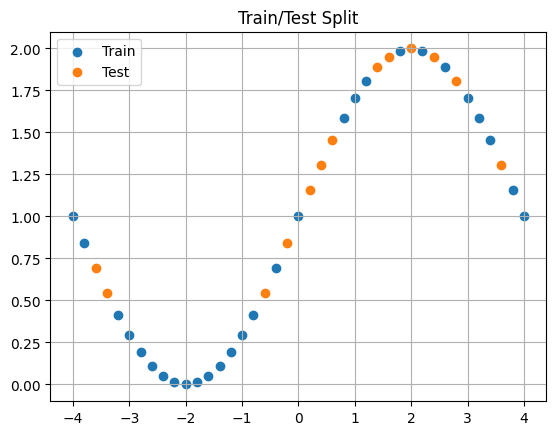

In [18]:
p = np.arange(-4, 4.1, 0.2)
f = 1 + np.sin(np.pi/4 * p)

X = p.reshape(-1,1)
y = f

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

plt.scatter(X_train, y_train, label='Train')
plt.scatter(X_test, y_test, label='Test')
plt.legend()
plt.title('Train/Test Split')
plt.grid()
plt.show()

## 3️⃣ Modelo Interactivo con Sliders

In [19]:
def entrenar(num_capas=1, neuronas=2, epochs=300):
    hidden = tuple([neuronas]*num_capas)
    model = MLPRegressor(hidden_layer_sizes=hidden,
                         activation='logistic',
                         #activation='tanh',
                         solver='lbfgs',
                         max_iter=epochs,
                         random_state=1)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    plt.figure(figsize=(8,5))
    plt.scatter(X, y, label='Real')
    plt.scatter(X, model.predict(X),  label='NN')
    plt.title(f'Train MSE={train_mse:.5f} | Test MSE={test_mse:.5f}')

    ptest = np.arange(-1.2, 1.2, 0.1)
    XtestN = ptest.reshape(-1,1)
    ytest_predN= model.predict(XtestN)
    plt.plot(XtestN, ytest_predN,'y', label='Pueba')
    plt.legend()
    plt.grid()
    plt.show()




In [20]:
interact(entrenar,
         num_capas=widgets.IntSlider(1,1,4,1),
         neuronas=widgets.IntSlider(2,1,50,1),
         epochs=widgets.IntSlider(300,50,1000,50));

interactive(children=(IntSlider(value=1, description='num_capas', max=4, min=1), IntSlider(value=2, descriptio…

## 4️⃣ Animación del Entrenamiento

In [21]:
hidden_layers = (2,)
model = MLPRegressor(hidden_layer_sizes=hidden_layers,
                     activation='logistic',
                     #activation='tanh',
                     solver='lbfgs',
                     max_iter=300,
                     warm_start=True,
                     random_state=1)

epochs = 300
errors_train = []
errors_test = []

fig, ax = plt.subplots()

def update(epoch):
    model.partial_fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    errors_train.append(mean_squared_error(y_train, y_train_pred))
    errors_test.append(mean_squared_error(y_test, y_test_pred))

    ax.clear()
    ax.plot(errors_train, label='Train Error')
    ax.plot(errors_test, label='Test Error')
    ax.set_title(f'Época {epoch+1}')
    ax.legend()
    ax.grid()

ani = FuncAnimation(fig, update, frames=epochs, interval=100)
plt.close()
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## 5️⃣ Evolución de Pesos

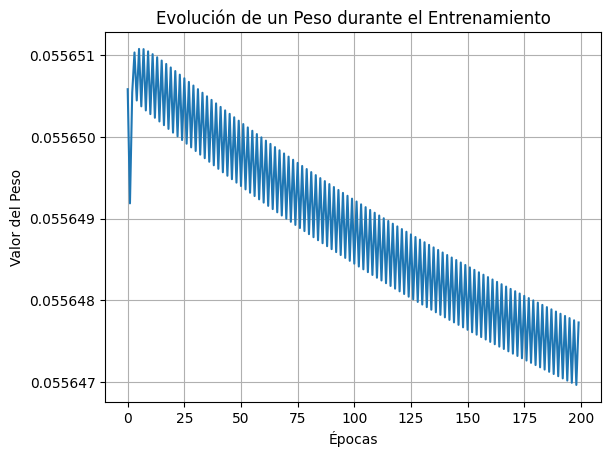

In [22]:
weights_history = []

model = MLPRegressor(hidden_layer_sizes=(2,),
                     activation='tanh',
                     solver='lbfgs',
                     max_iter=300,
                     warm_start=True,
                     random_state=1)

for i in range(200):
    model.partial_fit(X_train, y_train)
    weights_history.append(model.coefs_[0][0][0])

plt.plot(weights_history)
plt.title('Evolución de un Peso durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Valor del Peso')
plt.grid()
plt.show()

## 6️⃣ Visualización de Overfitting
Si el error de entrenamiento baja pero el de test sube → Overfitting.